# Exercise 01: Deep Reinforcement Learning
## AIAT 123 - Reinforcement Learning

---

## Learning Objectives

In this exercise, you will:
- Implement Deep Q-Networks (DQN)
- Use experience replay and target networks
- Train DQN agent on OpenAI Gym environment
- Evaluate agent performance

---

## Real-World Context

You are training a DQN agent to play a game (e.g., CartPole, LunarLander) using deep reinforcement learning.

---


## Exercise Brief

This exercise checks whether students can connect the key moving parts of deep RL in code.

The main goal is to practice network outputs, Bellman-style targets, and loss computation without hiding behind a large framework.

Why this matters: deep RL becomes much clearer when students can inspect the pieces separately before training a full agent.

This exercise is designed to reinforce that understanding.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


### Step Guide

**What this cell does:** Install or import dependencies so later cells can run.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Pip progress lines and usually a confirmation that imports work.

**If you feel lost:** Fix any red install error before continuing—later cells assume this cell succeeded.


## Student Support Pack

Use this section before coding so you know what the exercise is testing conceptually.

### Key Terms
- Agent: the decision maker.
- Environment: the world it acts in.
- Reward: feedback signal.
- Return: long-term reward total.

### Quick Check
- What core RL idea does this notebook teach?
- Which output best reflects the main concept?
- How would you explain this topic in one minute?

### Common Mistakes
- Focusing on syntax before meaning.
- Reading outputs without connecting them to the concept.
- Missing how one step fits the whole RL loop.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.
# The Gym extra is quoted so shells do not misread the square brackets.

# Line magic: Jupyter/IPython directive for this line only.
%pip install torch "gymnasium[classic-control]" numpy matplotlib -q

# Load a library so you can use its ready-made functions and types below.
import torch
# Load a library so you can use its ready-made functions and types below.
import torch.nn as nn
# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Show text or numbers in the cell output area under the code.
print("✅ Setup complete!")



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Task 1: DQN Components (50 points)

Build the four moving parts a DQN agent is made of, and inspect each one on its own.

**Requirements:**
- Build the Q-network architecture
- Implement an experience replay buffer (push + random sample)
- Create a target network and synchronize its weights
- Handle ε-greedy action selection from the network's Q-values

### Step Guide

**What this cell does:** Builds all four **DQN components** — the Q-network, a replay buffer (`push`/`sample`), a target network synchronized with `load_state_dict`, and ε-greedy action selection — and prints a small check for each.

**How to read it (weak Python OK):** Four short blocks, one per component. Each ends with a `print` that proves the piece works before any training exists.

**What to expect in the output:** The network layout, buffer sizes and one sampled minibatch, a target-sync check that flips from False to True, and two chosen actions (one random, one greedy).

**If you feel lost:** Read only the four printed checks — together they are the DQN parts list; the full training loop that combines them lives in `../examples/01_dqn_implementation.ipynb`.

In [2]:
# Task 1: build the four DQN components one by one and check each with a print.
# No training happens here — the goal is to hold each moving part in your hand first.

# Reproducible randomness for the checks below.
import random
torch.manual_seed(0)
random.seed(0)
np.random.seed(0)


# ── Component 1: the Q-network ──────────────────────────────────────────────
# Maps an observation (CartPole: 4 numbers) to one Q-value per action (2 actions).
class QNetwork(nn.Module):
    def __init__(self, obs_dim=4, act_dim=2):
        super().__init__()
        # Two hidden layers of 64 units; the LAST layer's outputs ARE the Q-values.
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, act_dim),
        )

    def forward(self, x):
        # Forward pass: observation in, vector of Q-values out.
        return self.net(x)


q_net = QNetwork()
print("Component 1 — Q-network architecture:")
print(q_net)


# ── Component 2: the experience replay buffer ───────────────────────────────
# A fixed-size FIFO store; training samples RANDOM minibatches to decorrelate updates.
from collections import deque


class ReplayBuffer:
    def __init__(self, capacity):
        # maxlen makes the deque drop the oldest transition once full.
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # Store one transition tuple.
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # Uniform random minibatch — the heart of experience replay.
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)


# Fill the buffer with toy transitions and pull one random minibatch.
buffer = ReplayBuffer(capacity=100)
for t in range(150):
    # Fake transition: the index t stands in for real environment data.
    buffer.push(state=t, action=t % 2, reward=1.0, next_state=t + 1, done=False)
minibatch = buffer.sample(4)
print(f"\nComponent 2 — replay buffer: pushed 150, holds {len(buffer)} (capacity 100)")
print("  One random minibatch (state indices):", sorted(tr[0] for tr in minibatch))


# ── Component 3: the target network ─────────────────────────────────────────
# A frozen copy of the Q-network that supplies STABLE Bellman targets;
# it is re-synchronized with the online network only every N training steps.
target_net = QNetwork()


def networks_match(a, b):
    # True when every parameter tensor in the two networks is identical.
    return all(torch.equal(pa, pb) for pa, pb in zip(a.parameters(), b.parameters()))


print(f"\nComponent 3 — target network freshly created, weights match online net? "
      f"{networks_match(q_net, target_net)}")
# The synchronization step DQN performs periodically:
target_net.load_state_dict(q_net.state_dict())
print(f"  After load_state_dict (the periodic sync), weights match? "
      f"{networks_match(q_net, target_net)}")


# ── Component 4: epsilon-greedy action selection ────────────────────────────
def select_action(network, state, epsilon):
    """With probability epsilon explore randomly; otherwise take the argmax Q action."""
    if random.random() < epsilon:
        return random.randrange(2), "random (explore)"
    with torch.no_grad():
        q_values = network(state)
    return int(q_values.argmax()), "greedy (exploit)"


# One example observation (CartPole-shaped) run through both regimes.
example_state = torch.tensor([0.02, -0.01, 0.03, 0.01])
a_explore = select_action(q_net, example_state, epsilon=1.0)
a_exploit = select_action(q_net, example_state, epsilon=0.0)
print(f"\nComponent 4 — action selection: eps=1.0 -> action {a_explore[0]} [{a_explore[1]}]")
print(f"                                eps=0.0 -> action {a_exploit[0]} [{a_exploit[1]}]")

print("\nTask 1 reflection: which of these four parts exists ONLY to stabilize training?")


Component 1 — Q-network architecture:
QNetwork(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

Component 2 — replay buffer: pushed 150, holds 100 (capacity 100)
  One random minibatch (state indices): [55, 99, 103, 147]

Component 3 — target network freshly created, weights match online net? False
  After load_state_dict (the periodic sync), weights match? True

Component 4 — action selection: eps=1.0 -> action 1 [random (explore)]
                                eps=0.0 -> action 0 [greedy (exploit)]

Task 1 reflection: which of these four parts exists ONLY to stabilize training?


## Task 2: The Bellman Target and DQN Loss (50 points)

Compute, by hand, the quantity a DQN training step minimizes — for one small batch.

**Requirements:**
- Build the Bellman target `r + γ·max Q(s',·)` for a batch of three transitions
- Zero the future term for terminal states with the `done` mask
- Compute the MSE loss between predicted and target Q-values
- Explain why the terminal mask matters (reflection question)

**Note on scope:** this exercise inspects the pieces — the full end-to-end DQN training loop that combines them is demonstrated in `../examples/01_dqn_implementation.ipynb`. The extension below trains a **REINFORCE** agent instead, so you still watch one complete training run here.

### Step Guide

**What this cell does:** Computes the **Bellman target** and the **MSE loss** for one hand-made batch of three transitions — the exact numbers a DQN optimizer would push the network toward.

**How to read it (weak Python OK):** Three parallel tensors describe three transitions. Follow one column (one transition) through target and loss.

**What to expect in the output:** The predicted Q-values, the computed targets (note the terminal one is exactly 0), and a single loss number.

**If you feel lost:** Check only the middle transition: `done=1` wipes out the future term, so its target is just the reward.

In [3]:
# Teaching note: this cell advances the lesson by building the next piece of the RL workflow.
# Run it after reading the comments so the output feels connected to the concept being taught.

# Task 2: compute a Bellman target and loss for one batch
# Save a value in a name so the next lines can read it.
q_pred = torch.tensor([1.2, 0.8, 1.5])
# Unpack the one-step model output from transition(state, action).
rewards = torch.tensor([1.0, 0.0, 1.0])
# Save a value in a name so the next lines can read it.
q_next = torch.tensor([1.3, 0.4, 1.8])
# Save a value in a name so the next lines can read it.
done = torch.tensor([0.0, 1.0, 0.0])
# Save a value in a name so the next lines can read it.
gamma = 0.99

# Save a value in a name so the next lines can read it.
q_target = rewards + gamma * q_next * (1 - done)
# Save a value in a name so the next lines can read it.
loss = nn.MSELoss()(q_pred, q_target)

# Show text or numbers in the cell output area under the code.
print("Predicted Q values:", q_pred)
# Show text or numbers in the cell output area under the code.
print("Target Q values:", q_target)
# Show text or numbers in the cell output area under the code.
print("Loss:", round(loss.item(), 4))
# Show text or numbers in the cell output area under the code.
print("\nTask 2 reflection: why do terminal states remove the future term?")


Predicted Q values: tensor([1.2000, 0.8000, 1.5000])
Target Q values: tensor([2.2870, 0.0000, 2.7820])
Loss: 1.155

Task 2 reflection: why do terminal states remove the future term?


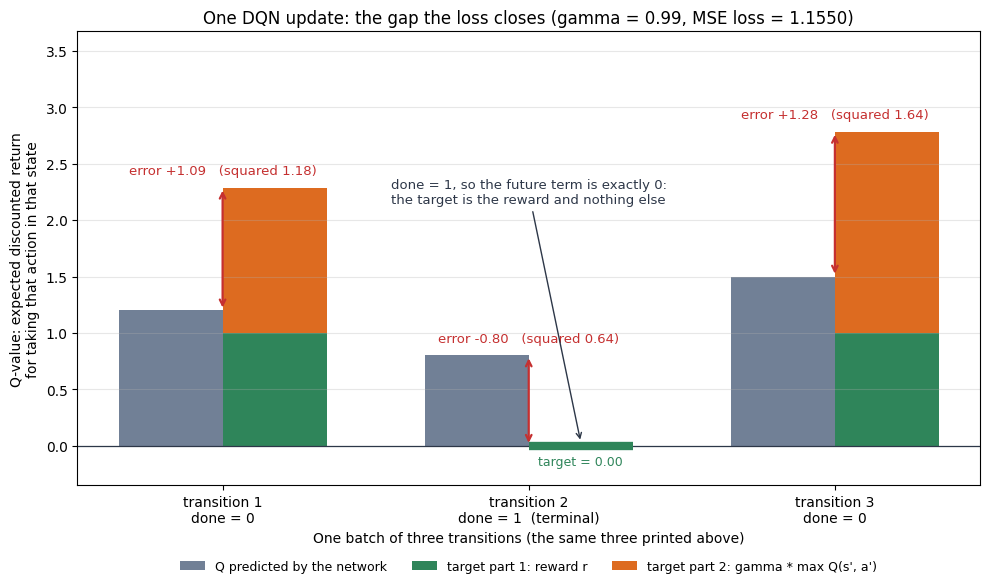

In [4]:
# Draw the three transitions you just computed, so the terminal mask is visible and not just asserted.
# Nothing new is calculated: every number below comes from q_pred, rewards, q_next, done and gamma above.

# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Pull the tensors into plain Python lists so matplotlib can draw them.
pred = q_pred.tolist()
targ = q_target.tolist()
reward_part = rewards.tolist()
# The future term is the part the terminal mask can switch off.
future_part = (gamma * q_next * (1 - done)).tolist()
labels = [f"transition {i + 1}\ndone = {int(d)}" + ("  (terminal)" if d else "") for i, d in enumerate(done.tolist())]

x = list(range(len(pred)))
width = 0.34
fig, ax = plt.subplots(figsize=(10.0, 6.0))

# Left bar of each pair: what the network currently says.
ax.bar([i - width / 2 for i in x], pred, width, color="#718096", label="Q predicted by the network")
# Right bar of each pair: the target, split into the two terms it is made of.
ax.bar([i + width / 2 for i in x], reward_part, width, color="#2f855a", label="target part 1: reward r")
ax.bar([i + width / 2 for i in x], future_part, width, bottom=reward_part, color="#dd6b20",
       label="target part 2: gamma * max Q(s', a')")

# A target of exactly 0 draws no bar at all, so mark it explicitly instead of leaving a blank gap.
for i, t in enumerate(targ):
    if abs(t) < 1e-9:
        ax.plot([i + width / 2 - width / 2, i + width / 2 + width / 2], [0, 0],
                color="#2f855a", lw=6, solid_capstyle="butt", zorder=5)
        ax.text(i + width / 2, -0.17, "target = 0.00", ha="center", fontsize=9, color="#2f855a")

# Show the error the loss is built from as a vertical span between the two bar heights.
for i, (p, t) in enumerate(zip(pred, targ)):
    ax.annotate("", xy=(i, t), xytext=(i, p),
                arrowprops=dict(arrowstyle="<->", color="#c53030", lw=1.6))
    ax.text(i, max(p, t) + 0.12, f"error {t - p:+.2f}   (squared {(t - p) ** 2:.2f})",
            ha="center", fontsize=9.5, color="#c53030")

# Name the terminal transition in the picture itself - it is the whole point of the mask.
ax.annotate("done = 1, so the future term is exactly 0:\nthe target is the reward and nothing else",
            xy=(1 + width / 2, 0.03), xytext=(1.0, 2.15),
            ha="center", fontsize=9.5, color="#2d3748",
            arrowprops=dict(arrowstyle="->", color="#2d3748"))

# Draw the zero line so a zero-height bar is readable as "zero", not as "missing".
ax.axhline(0, color="#2d3748", lw=0.9)
ax.set_ylim(-0.35, max(max(pred), max(targ)) * 1.32)
ax.set_xticks(x, labels=labels)
ax.set_xlabel("One batch of three transitions (the same three printed above)")
ax.set_ylabel("Q-value: expected discounted return\nfor taking that action in that state")
ax.set_title(f"One DQN update: the gap the loss closes (gamma = {gamma}, MSE loss = {loss.item():.4f})")
# The legend sits under the axes so it can never cover a bar or an error label.
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, fontsize=9, frameon=False)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
# Draw the figure in the notebook output area.
plt.show()


### 👁️ Read the figure

- **Each pair of bars is one transition.** The grey bar is what the network currently predicts; the stacked bar next to it is the Bellman target it is being pulled toward, split into the two pieces that build it: the green reward `r`, and the orange discounted future `γ · max Q(s', a')`. The red arrow between them is the error, and its square is the number that goes into the loss. Averaging the three squared errors gives the single loss in the title — nothing else is in it (the labels are rounded to two decimals, the loss is not).
- **The middle pair is the lesson.** Transition 2 is terminal (`done = 1`), so it has **no orange segment at all**. Its target is 0.00 — the reward, which happens to be 0 here, and nothing more. Compare it with transitions 1 and 3, where orange is the larger part of the target. That is the terminal mask `(1 - done)` doing its one job.
- **Why forgetting the mask is so damaging.** Without it, transition 2's target becomes `0 + 0.99 × 0.4 = 0.40`, and the network is taught that an episode which *ended* still has value ahead of it. That invented value is then bootstrapped into the states that led there, and into the states before those — the error does not stay local, it flows backwards through the whole table.
- **The biggest arrow is not the most interesting one.** Transition 3 carries the largest squared error (1.64), but it is an ordinary under-estimate that training will fix. Transition 2's arrow is small and still matters more, because it is the one whose *shape* would be wrong if the mask were missing.
- These numbers are hand-made on purpose: three transitions you can check with a calculator, before any of it is buried inside a training loop.



---

## Submission

**Submission**: Complete notebook with all tasks implemented

**Grading**: 100 points total


## 🌍 Extension Example — REINFORCE on CartPole

**Industry context:**
- Policy-gradient methods are used in robotics and continuous-control research
- More advanced policy-gradient variants, such as PPO, are common in modern RL systems
- This example is included as an extension, not as the main exercise target

We implement **REINFORCE** on CartPole-v1 as a contrast to DQN, so students can see that deep RL includes both value-based and policy-gradient methods.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Episode   0 | Avg reward: 13.0
Episode  50 | Avg reward: 16.4


Episode 100 | Avg reward: 31.5


Episode 150 | Avg reward: 56.7


Episode 200 | Avg reward: 129.9


Episode 250 | Avg reward: 245.3


Episode 300 | Avg reward: 386.1


Episode 350 | Avg reward: 365.6


Episode 400 | Avg reward: 454.8


Episode 450 | Avg reward: 449.8


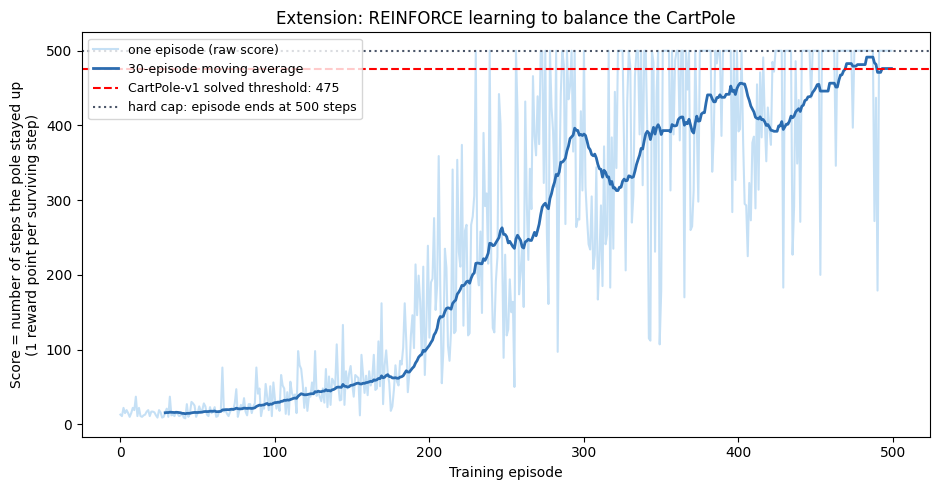

In [5]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42)
# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')
# Seeding torch alone is NOT enough: the environment has its own random generator, and it decides
# the starting angle of every episode. Seed it too, or this training curve is different every run.
env.reset(seed=42)
env.action_space.seed(42)
np.random.seed(42)

# Class `PolicyNet` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class PolicyNet(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self.
    def __init__(self):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(4, 128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, 2), nn.Softmax(dim=-1)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy  = PolicyNet()
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy.parameters(), lr=2e-3)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; ep_rewards = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(500):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); log_probs=[]; rewards_ep=[]
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(500):
        # Save a value in a name so the next lines can read it.
        probs  = policy(torch.tensor(obs).float().unsqueeze(0))
        # Save a value in a name so the next lines can read it.
        dist   = torch.distributions.Categorical(probs)
        # Save a value in a name so the next lines can read it.
        action = dist.sample()
        # Add one new item to the end of a list (the list grows in place).
        log_probs.append(dist.log_prob(action))
        # Save a value in a name so the next lines can read it.
        obs, r, done, trunc, _ = env.step(action.item())
        # Add one new item to the end of a list (the list grows in place).
        rewards_ep.append(r)
        # If the condition is True, run the indented block under this line.
        if done or trunc: break

    # ── Compute discounted returns ──────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    G = 0; returns = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for r in reversed(rewards_ep):
        # Save a value in a name so the next lines can read it.
        G = r + GAMMA*G; returns.insert(0, G)
    # Save a value in a name so the next lines can read it.
    returns = torch.tensor(returns).float()
    # Save a value in a name so the next lines can read it.
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    # ── Policy gradient loss ────────────────────────────────────────────────
    # Save a value in a name so the next lines can read it.
    loss = -torch.stack([lp*R for lp,R in zip(log_probs, returns)]).sum()
    # Execute: opt.zero_grad(); loss.backward(); opt.step()
    opt.zero_grad(); loss.backward(); opt.step()
    # Add one new item to the end of a list (the list grows in place).
    ep_rewards.append(sum(rewards_ep))
    # If the condition is True, run the indented block under this line.
    if episode%50==0: print(f"Episode {episode:3d} | Avg reward: {np.mean(ep_rewards[-20:]):.1f}")

# Execute: env.close()
env.close()
# Save a value in a name so the next lines can read it.
ma = np.convolve(ep_rewards, np.ones(30)/30, 'valid')
# One figure: how long the pole stayed up, episode by episode, while the policy was learning.
plt.figure(figsize=(9.5, 5.0))
# Raw per-episode scores are faint because they are noisy - policy gradients are high-variance.
plt.plot(ep_rewards, alpha=0.3, color="#4299e1", label="one episode (raw score)")
# The moving average starts at episode 30, since that is the first window it can cover.
plt.plot(range(29, 29 + len(ma)), ma, lw=2, color="#2b6cb0", label="30-episode moving average")
# CartPole-v1 is officially "solved" at an average score of 475 over 100 consecutive episodes.
plt.axhline(475, color="red", linestyle="--", label="CartPole-v1 solved threshold: 475")
# The environment stops every episode at 500 steps, so no score can ever go above this line.
plt.axhline(500, color="#4a5568", linestyle=":", label="hard cap: episode ends at 500 steps")
plt.title("Extension: REINFORCE learning to balance the CartPole")
plt.xlabel("Training episode")
plt.ylabel("Score = number of steps the pole stayed up\n(1 reward point per surviving step)")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


### 👁️ Read the figure

- **The dark line is the story: from about 13 steps to the high hundreds.** For the first ~150 episodes the pole falls almost immediately (the log prints an average of 13.0 over the first 20 episodes, and the curve is flat and low). Lift-off happens between roughly episode 180 and 300. The agent was never told how to balance a pole; it only ever received +1 for each step it survived, and it worked backwards from that to a policy.
- **Now read the part that tutorials crop out: the curve is not monotonic.** In the run stored here the 30-episode average peaks near 395 around episode 295, **falls back to about 315 by episode 325**, recovers past 450 by episode 400, sags again near episode 430, and only crosses the red *solved* line in the last thirty-odd episodes. REINFORCE updates from whole-episode returns, so a handful of unlucky rollouts genuinely moves the weights the wrong way. "It touched the threshold once" is not "it is solved" — read where the curve *ends*, and how long it stayed there.
- **The faint blue spikes are the variance, not noise in the drawing.** Even after episode 450, individual episodes still end at 200 steps or fewer. That spread is why the raw score is drawn faintly behind an average instead of being reported on its own.
- **Read the two horizontal lines correctly.** The dotted line at 500 is a *hard cap*: the environment truncates every episode at 500 steps, so nothing can be plotted above it, and touching it does not mean "balanced forever". The red line at 475 is the official CartPole-v1 solved bar, and the official definition averages over **100** consecutive episodes — this is a 30-episode average, an easier test.
- **This is an extension, not the DQN.** The curve shows a *policy-gradient* agent, which adjusts action probabilities directly. The DQN parts you built above learn action values instead and produce a differently-shaped run. Both are deep RL; they disagree about what the network should output.
- Torch **and** the environment are seeded (`torch.manual_seed(42)`, `env.reset(seed=42)`), so re-running this notebook reproduces this curve rather than a new one each time. If you change the learning rate, the seed, or the network and your curve stops matching this paragraph, trust the curve.


## 📝 Summary

In this notebook, you practiced:
- Building the four **DQN components** in isolation: a Q-network, an experience **replay buffer** with random minibatch sampling, a **target network** synchronized via `load_state_dict`, and ε-greedy action selection
- Computing the **Bellman target** `r + γ·max Q(s',·)` and its **MSE loss** by hand for a small batch, including the terminal-state mask
- Watching one complete training run in the extension: a **REINFORCE** policy-gradient agent on CartPole with a learning-curve plot

**Next steps:** open `../examples/01_dqn_implementation.ipynb` to see these DQN components assembled into a full training loop, then experiment with the optimization tricks from `../examples/06_optimization_experience_replay_reward_shaping.ipynb`.

In [6]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Papers
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

### State-of-the-art
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control
"""))


## 📚 References & Further Reading

### Papers
- Williams (1992) — [REINFORCE](https://link.springer.com/article/10.1007/BF00992696)
- Schulman et al. (2017) — [PPO: Proximal Policy Optimization](https://arxiv.org/abs/1707.06347)
- Mnih et al. (2016) — [A3C: Asynchronous Methods for Deep RL](https://arxiv.org/abs/1602.01783)

### State-of-the-art
- OpenAI's ChatGPT uses RLHF (PPO) to align responses with human preferences
- Boston Dynamics robots use PPO for locomotion control


## Closing Takeaway

**Teaching takeaway:** This exercise checks whether students can interpret deep RL components and training behavior, not just repeat terminology.

**If students remember one idea:** Students should leave this unit able to explain what each major deep RL component is doing during learning.

**Quick check before moving on:**
- Can you connect each deep RL component to the specific problem it solves?
- Can you explain how you would diagnose an unstable training run?

**Bridge to the next step:** After this exercise, the course shifts to a dedicated study of exploration and exploitation trade-offs.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=11 | term=True | trunc=False


objc[60199]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11c9c4138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11cec09c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[60199]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11c9c4188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11cec0a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[60199]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11c9c3c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11cec0a68). T

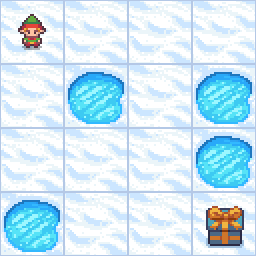

In [7]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Find the shared Course 09 helper (course09_step_viz.py) from ANY folder, and on Google Colab.
# WHAT: look for the helper up the folder chain, then inside a "Course 09" folder on that chain,
#       and only then download it; finally put its folder on Python's import path.
# WHY:  searching only the PARENTS of the working directory breaks the moment you open this
#       notebook from the repository root - there the helper sits in a child folder, not a
#       parent - and on Colab there is no repository at all. This does not care where you
#       started the kernel from.
_HELPER_C9 = "course09_step_viz.py"
_chain_c9 = [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
_course09 = next((d for d in _chain_c9 if (d / _HELPER_C9).exists()), None)
if _course09 is None:                      # opened from the repo root, or from another course
    _course09 = next((d / "Course 09" for d in _chain_c9
                      if (d / "Course 09" / _HELPER_C9).exists()), None)
if _course09 is None:                      # Google Colab, or a stray copy of this notebook
    import urllib.request
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
            "Course%2009/" + _HELPER_C9, _HELPER_C9)
    except Exception as _e:
        raise FileNotFoundError(
            f"Could not find {_HELPER_C9} from this folder, and could not download it either. "
            "Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet and "
            f"re-run this cell. (underlying error: {_e})") from None
    _course09 = pathlib.Path.cwd()

# Put that folder on Python's import path so the helper imports from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
